# 🍃 Day 26 - Air Quality Index (AQI) Prediction
### Forecasting Air Quality Index using pollutant concentrations, meteorological variables, and ensemble-based regression models

In [1]:
# 0. Installs (run in terminal / notebook cell once)
# !pip install pandas numpy scikit-learn matplotlib seaborn lightgbm joblib

# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import joblib
import warnings
warnings.filterwarnings("ignore")
sns.set_style("darkgrid")

In [2]:
# 2. Which file to use
# Prefer city_day.csv for daily city-level AQI. If you want station_day.csv, change filename.
FILENAME = "city_day.csv"

In [3]:
# 3. Load
df = pd.read_csv(FILENAME)
print("Rows,cols:", df.shape)
display(df.head())
display(df.info())

Rows,cols: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


None

In [4]:
# 4. Basic inspection of relevant columns
print("\nColumns sample:", df.columns.tolist()[:40])
print("\nMissing fraction (top):")
display(df.isna().mean().sort_values(ascending=False).head(20))


Columns sample: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Missing fraction (top):


Xylene        0.613220
PM10          0.377231
NH3           0.349734
Toluene       0.272290
Benzene       0.190410
AQI           0.158511
AQI_Bucket    0.158511
PM2.5         0.155701
NOx           0.141715
O3            0.136196
SO2           0.130507
NO2           0.121398
NO            0.121296
CO            0.069723
Date          0.000000
City          0.000000
dtype: float64

In [5]:
# 5. Parse date - try common column names
date_col = None
for c in df.columns:
    if c.lower() in ("date", "datetime", "timestamp"):
        date_col = c
        break
if date_col is None:
    # fallback: column with 'date' in name
    for c in df.columns:
        if "date" in c.lower() or "time" in c.lower():
            date_col = c
            break
if date_col is None:
    raise ValueError("Can't find a date column. Inspect df.columns and pick the date column manually.")

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
df.rename(columns={date_col: "date"}, inplace=True)

In [6]:
# 6. Choose pollutants and target
# Look for common pollutant column names; print what we find
possible_pollutants = ["PM2.5", "PM25", "PM_2_5", "PM10", "NO2", "SO2", "CO", "O3", "NH3", "benzene", "toluene"]
found = [c for c in df.columns if any(p.lower() == c.lower() or p.lower()==c.replace('.','').lower() for p in possible_pollutants)]
print("Possible pollutant columns found:", found)

# Check for AQI column
aqicol = None
for c in df.columns:
    if c.lower() in ("aqi", "air_quality_index", "aqi_value"):
        aqicol = c
        break

print("AQI column found:", aqicol)

Possible pollutant columns found: ['PM2.5', 'PM10', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
AQI column found: AQI


In [7]:
# 7. If no AQI, compute a simple AQI from PM2.5 and PM10 only (basic approach)
# Note: This is simplified. Full AQI uses breakpoint tables per pollutant (CPCB/EPA). 
def aqi_subindex(conc, breakpoints):
    # breakpoints: list of tuples (C_low, C_high, I_low, I_high)
    for C_low, C_high, I_low, I_high in breakpoints:
        if C_low <= conc <= C_high:
            return ((I_high - I_low) / (C_high - C_low)) * (conc - C_low) + I_low
    # if above highest breakpoint, linear extrapolation using last segment
    C_low, C_high, I_low, I_high = breakpoints[-1]
    return ((I_high - I_low) / (C_high - C_low)) * (conc - C_low) + I_low

# CPCB-like breakpoints (approx) for PM2.5 (µg/m3) and PM10 (µg/m3).
# These are example bins; if you need exact CPCB bins, replace them with official tables.
pm25_bp = [
    (0, 30, 0, 50),
    (31, 60, 51, 100),
    (61, 90, 101, 200),
    (91, 120, 201, 300),
    (121, 250, 301, 400),
    (251, 99999, 401, 500)
]
pm10_bp = [
    (0, 50, 0, 50),
    (51, 100, 51, 100),
    (101, 250, 101, 200),
    (251, 350, 201, 300),
    (351, 430, 301, 400),
    (431, 99999, 401, 500)
]

if not aqicol:
    # try to find pm columns
    pm25_col = None
    pm10_col = None
    for c in df.columns:
        if c.lower().replace('.','') in ("pm25","pm2_5","pm_25","pm_2_5"):
            pm25_col = c
        if c.lower().replace('.','') in ("pm10","pm_10"):
            pm10_col = c
    print("Detected PM2.5:", pm25_col, "PM10:", pm10_col)
    if pm25_col is None and pm10_col is None:
        raise ValueError("No PM2.5 or PM10 column detected. Pick station_day or city_day file with these columns.")
    # compute AQI using whichever pollutant available and take the max subindex (standard practice)
    def compute_aqi_row(row):
        subs = []
        if pm25_col and not pd.isna(row[pm25_col]):
            subs.append(aqi_subindex(row[pm25_col], pm25_bp))
        if pm10_col and not pd.isna(row[pm10_col]):
            subs.append(aqi_subindex(row[pm10_col], pm10_bp))
        if len(subs)==0: 
            return np.nan
        return max(subs)  # overall AQI is max of sub-indices
    df['AQI_computed'] = df.apply(compute_aqi_row, axis=1)
    target = 'AQI_computed'
else:
    target = aqicol

print("Using target:", target)
print("Target missing fraction:", df[target].isna().mean())

Using target: AQI
Target missing fraction: 0.15851139480545867


In [8]:
# 8. Build modeling dataframe: choose features (pollutants + meteorological if present)
# We'll use numeric columns only (pollutants + temp/humidity/wind etc.)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# exclude target from features
if target in numeric_cols: 
    numeric_cols.remove(target)
# remove obviously irrelevant numeric ids if present (for safety)
for c in ["id","index","serial"]:
    if c in numeric_cols:
        numeric_cols.remove(c)

print("Numeric candidate features:", numeric_cols)

# Keep features that are meaningful (pollutants & meteo)
# If too many numeric columns, pick the intersection with known pollutant/meteorological names:
preferred_features = []
for c in numeric_cols:
    low = c.lower()
    if any(k in low for k in ["pm","pm2","pm10","no2","so2","co","o3","nh3","temp","humidity","wind","pressure","rain"]):
        preferred_features.append(c)
# fallback: if none found, use first 6 numeric columns
if not preferred_features:
    preferred_features = numeric_cols[:6]
print("Selected features:", preferred_features)

Numeric candidate features: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
Selected features: ['PM2.5', 'PM10', 'NO2', 'NH3', 'CO', 'SO2', 'O3']


In [9]:
# 9. Build modeling dataframe (drop rows missing AQI target)
model_df = df.dropna(subset=[target]).copy()

# --- NEW: Sort by city + date for proper lagging ---
model_df = model_df.sort_values(['City','date']).reset_index(drop=True)

# --- NEW: Add lag features ---
model_df['AQI_lag1'] = model_df.groupby('City')[target].shift(1)
model_df['AQI_lag3'] = model_df.groupby('City')[target].shift(3)
model_df['AQI_ma7'] = (
    model_df.groupby('City')[target]
    .shift(1)
    .rolling(window=7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# --- NEW: Add date features ---
model_df['month'] = model_df['date'].dt.month
model_df['dayofweek'] = model_df['date'].dt.dayofweek

# Drop rows where lag1 is missing (simple clean-up)
model_df = model_df.dropna(subset=['AQI_lag1']).reset_index(drop=True)

# --- NEW: Update feature list with lags ---
preferred_features = [
    'PM2.5','PM10','NO2','NH3','CO','SO2','O3',
    'AQI_lag1','AQI_lag3','AQI_ma7','month','dayofweek'
]

# Now create X, y with the updated features
X = model_df[preferred_features].copy()
y = model_df[target].astype(float).copy()

dates = model_df['date'].copy()
cities = model_df['City'] if 'City' in model_df.columns else None

print("Model rows after lag features:", len(X))
print("Features used:", preferred_features)

Model rows after lag features: 24824
Features used: ['PM2.5', 'PM10', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'AQI_lag1', 'AQI_lag3', 'AQI_ma7', 'month', 'dayofweek']


In [10]:
# 10. Impute & scale pipeline for numeric features
num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_imputed = num_imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

In [11]:
# 11. Time-aware split: keep last 20% as test set (per city if city exists)
def time_split_arrays(X_arr, y_arr, dates_arr, frac_test=0.2, group_by=None):
    if group_by is None:
        n = len(dates_arr)
        split = int(n * (1 - frac_test))
        return X_arr[:split], X_arr[split:], y_arr[:split], y_arr[split:], dates_arr[:split], dates_arr[split:]
    # group-aware splitting (concatenate per group)
    X_tr_list, X_te_list, y_tr_list, y_te_list = [], [], [], []
    dates_tr_list, dates_te_list = [], []
    for g in np.unique(group_by):
        mask = (group_by == g)
        idx = np.argsort(dates_arr[mask].astype(np.int64))
        group_X = X_arr[mask]
        group_y = y_arr[mask]
        group_dates = dates_arr[mask]
        n = len(group_dates)
        if n < 10:
            # skip small groups by putting all into train
            X_tr_list.append(group_X)
            y_tr_list.append(group_y)
            dates_tr_list.append(group_dates)
            continue
        split = int(n * (1 - frac_test))
        X_tr_list.append(group_X[idx][:split])
        X_te_list.append(group_X[idx][split:])
        y_tr_list.append(group_y[idx][:split])
        y_te_list.append(group_y[idx][split:])
        dates_tr_list.append(group_dates[idx][:split])
        dates_te_list.append(group_dates[idx][split:])
    if len(X_te_list)==0:  # fallback
        return X_arr, np.empty((0, X_arr.shape[1])), y_arr, np.empty((0,)), dates_arr, np.empty((0,), dtype='datetime64[ns]')
    X_train = np.vstack(X_tr_list)
    X_test = np.vstack(X_te_list)
    y_train = np.hstack(y_tr_list)
    y_test = np.hstack(y_te_list)
    dates_train = pd.concat(dates_tr_list).reset_index(drop=True)
    dates_test = pd.concat(dates_te_list).reset_index(drop=True)
    return X_train, X_test, y_train, y_test, dates_train, dates_test

group_vals = model_df['city'].values if 'city' in model_df.columns else None
X_train, X_test, y_train, y_test, dates_train, dates_test = time_split_arrays(X_scaled, y.values, pd.Series(dates.values), frac_test=0.2, group_by=group_vals)

print("Train rows:", len(X_train), "Test rows:", len(X_test))

Train rows: 19859 Test rows: 4965


In [12]:
# 12. Baseline model: Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,  # fixed
        "R2": r2_score(y_true, y_pred)
    }
print("RF metrics:", metrics(y_test, y_pred))

RF metrics: {'MAE': 14.121805639476333, 'RMSE': 22.09305935643793, 'R2': 0.9577094672617558}


In [13]:
# 13. Optional: LightGBM if installed (faster)
try:
    from lightgbm import LGBMRegressor
    lgb = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
    lgb.fit(X_train, y_train)
    y_lgb = lgb.predict(X_test)
    print("LGB metrics:", metrics(y_test, y_lgb))
    # Simple average ensemble
    y_avg = (y_pred + y_lgb) / 2
    print("Avg ensemble metrics:", metrics(y_test, y_avg))
except Exception as e:
    print("LightGBM not available or failed:", e)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2571
[LightGBM] [Info] Number of data points in the train set: 19859, number of used features: 12
[LightGBM] [Info] Start training from score 170.914094
LGB metrics: {'MAE': 14.093224224500732, 'RMSE': 21.71961277178991, 'R2': 0.959127086736666}
Avg ensemble metrics: {'MAE': 13.717156322932395, 'RMSE': 21.32517025520864, 'R2': 0.9605981646712513}


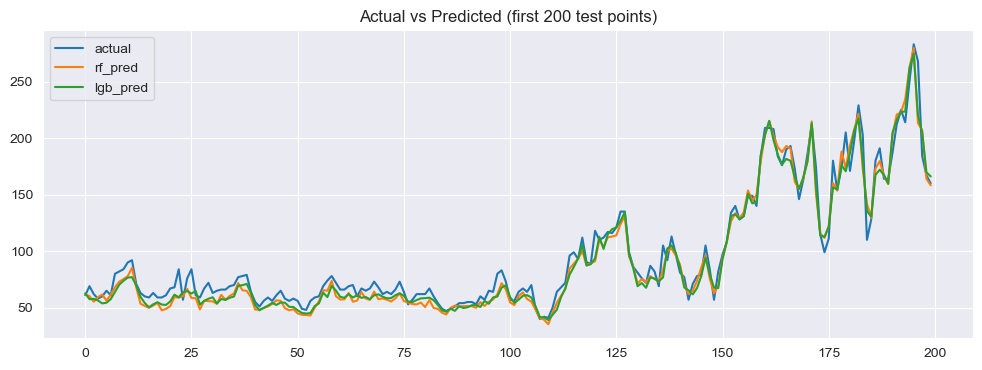

In [14]:
# 14. Diagnostics: plot actual vs predicted for a small slice
plt.figure(figsize=(12,4))
n_plot = min(200, len(y_test))
plt.plot(y_test[:n_plot], label="actual")
plt.plot(y_pred[:n_plot], label="rf_pred")
if 'y_lgb' in locals():
    plt.plot(y_lgb[:n_plot], label="lgb_pred")
plt.legend()
plt.title("Actual vs Predicted (first {} test points)".format(n_plot))
plt.show()

AQI_lag1     0.608136
CO           0.237124
PM2.5        0.095674
PM10         0.014113
AQI_ma7      0.009897
O3           0.007786
SO2          0.007137
AQI_lag3     0.006448
NO2          0.006061
month        0.002980
dayofweek    0.002647
NH3          0.001998
dtype: float64

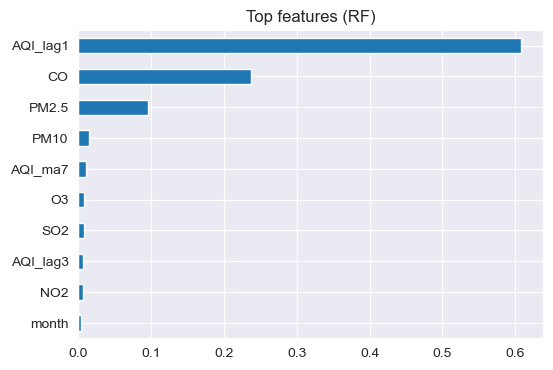

In [15]:
# 15. Feature importance (for RF)
fi = rf.feature_importances_
feat_imp = pd.Series(fi, index=preferred_features).sort_values(ascending=False)
display(feat_imp)
plt.figure(figsize=(6,4))
feat_imp.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top features (RF)")
plt.show()

In [16]:
# 16. Save preprocessor and model
joblib.dump({"imputer": num_imputer, "scaler": scaler, "features": preferred_features}, "preprocessor.joblib")
joblib.dump(rf, "rf_aqi_model.joblib")
print("Saved preprocessor.joblib and rf_aqi_model.joblib")

Saved preprocessor.joblib and rf_aqi_model.joblib


In [17]:
# 17. Quick predict example (use last available row)
last_row = X_scaled[-1].reshape(1, -1)
print("Last date:", dates.iloc[-1])
print("Predicted AQI (RF) for last row:", rf.predict(last_row)[0])

Last date: 2020-07-01 00:00:00
Predicted AQI (RF) for last row: 58.23
